In [20]:
# === FULL SIAMESE NETWORK WITH RESNET BACKBONE, CONTRASTIVE LOSS, TRAINING + TSNE ===

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50,ResNet50_Weights
from PIL import Image
import os
import random
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [26]:
# === 1. SIAMESE NETWORK MODEL WITH RESNET BACKBONE ===
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        base_model = resnet50(pretrained=True)
        base_model.fc = nn.Identity()  # Remove final classification layer

        self.prep = nn.Identity()
        self.cnn = base_model

    def forward_once(self, x):
        x = self.prep(x)
        if x.shape[1] == 1:           # If grayscale, repeat channels to make 3
            x = x.repeat(1, 3, 1, 1)
        x = self.cnn(x)
        x = F.normalize(x, p=2, dim=1)  # Normalize embeddings
        return x

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2



In [28]:

# === 2. CUSTOM DATASET FOR PAIRS ===
class SiameseDataset(Dataset):
    def __init__(self, image_folder_dataset, transform=None):
        self.image_folder_dataset = image_folder_dataset
        self.transform = transform
        self.classes = list(image_folder_dataset.class_to_idx.keys())
        self.class_to_images = {cls: [] for cls in self.classes}

        for img_path, label in image_folder_dataset.samples:
            cls_name = self.classes[label]
            self.class_to_images[cls_name].append(img_path)

    def __getitem__(self, index):
        cls1 = random.choice(self.classes)
        is_same = random.randint(0, 1)

        img1_path = random.choice(self.class_to_images[cls1])
        img1 = Image.open(img1_path).convert("L")

        if is_same:
            img2_path = random.choice(self.class_to_images[cls1])
        else:
            cls2 = random.choice([c for c in self.classes if c != cls1])
            img2_path = random.choice(self.class_to_images[cls2])

        img2 = Image.open(img2_path).convert("L")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label = torch.tensor(float(is_same), dtype=torch.float32)
        return img1, img2, label

    def __len__(self):
        return sum(len(paths) for paths in self.class_to_images.values())


In [29]:
# === 3. CONTRASTIVE LOSS FUNCTION ===
def contrastive_loss(output1, output2, label, margin=1.0):
    dist = F.pairwise_distance(output1, output2)
    loss = label * dist.pow(2) + (1 - label) * F.relu(margin - dist).pow(2)
    return loss.mean()


In [30]:
# === 4. DATA LOADING ===
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])

image_folder = ImageFolder("/kaggle/input/flowers-recognition/flowers", transform=None)
dataset = SiameseDataset(image_folder, transform=transform)
dataloader = DataLoader(dataset, shuffle=True, batch_size=32)


In [31]:
# === 5. TRAINING ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNetwork().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(5):  # Change to more epochs if needed
    model.train()
    total_loss = 0
    for img1, img2, label in dataloader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        loss = contrastive_loss(out1, out2, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader):.4f}")

Epoch 1, Loss: 0.2455
Epoch 2, Loss: 0.2184
Epoch 3, Loss: 0.1912
Epoch 4, Loss: 0.1827
Epoch 5, Loss: 0.1527


In [32]:
# === 6. EXTRACT EMBEDDINGS FOR T-SNE ===
model.eval()
all_embeddings = []
all_labels = []

In [33]:
# Reuse ImageFolder with transforms
full_dataset = ImageFolder("/kaggle/input/flowers-recognition/flowers", transform=transform)
loader = DataLoader(full_dataset, batch_size=64, shuffle=False)

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)
        embeddings = model.forward_once(images)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

all_embeddings = np.concatenate(all_embeddings)
all_labels = np.concatenate(all_labels)


In [37]:
from torch.utils.data import Dataset
from PIL import Image
import os

class FlowerFeatureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        for cls in self.class_names:
            cls_path = os.path.join(root_dir, cls)
            if os.path.isdir(cls_path):
                for fname in os.listdir(cls_path):
                    fpath = os.path.join(cls_path, fname)
                    if os.path.isfile(fpath):
                        self.image_paths.append(fpath)
                        self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("L")  # Grayscale to match Siamese input
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


In [47]:
import torch
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)
all_features = []
all_labels = []

with torch.no_grad():
    for img1, img2, labels in dataloader:
        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.to(device)

        emb1 = model.forward_once(img1)
        emb2 = model.forward_once(img2)

        # Example: just use embeddings from img1
        all_features.append(emb1.cpu())
        all_labels.append(labels.cpu())

all_features = torch.cat(all_features)
all_labels = torch.cat(all_labels)

features_np = all_features.numpy()
labels_np = all_labels.numpy()

# Proceed with t-SNE and DataFrame creation as before


In [51]:
import torch
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)

all_features = []
all_labels = []

with torch.no_grad():
    for img1, img2, labels in dataloader:
        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.to(device)

        emb1 = model.forward_once(img1)
        # Optionally, also emb2 = model.forward_once(img2)

        all_features.append(emb1.cpu())
        all_labels.append(labels.cpu())

# Concatenate batches
features = torch.cat(all_features)  # This creates the features tensor
labels = torch.cat(all_labels)

# Convert to numpy
features_np = features.numpy()
labels_np = labels.numpy()

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(features_np)

# Create DataFrame for visualization
labels_int = labels_np.astype(int)

df = pd.DataFrame({
    'x': tsne_result[:, 0],
    'y': tsne_result[:, 1],
    'class': [feature_dataset.classes[label] for label in labels_int]
})


print(df.head())


           x          y      class
0 -20.201210  54.018547  dandelion
1 -33.865170 -50.073597  dandelion
2 -25.041002 -10.320102      daisy
3 -27.844969 -51.331104      daisy
4  21.384212 -61.636353      daisy


In [52]:
class FlowerFeatureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        for cls in self.class_names:
            cls_path = os.path.join(root_dir, cls)
            if os.path.isdir(cls_path):
                for fname in os.listdir(cls_path):
                    fpath = os.path.join(cls_path, fname)
                    if os.path.isfile(fpath):
                        self.image_paths.append(fpath)
                        self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("L")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


In [56]:
from tqdm import tqdm

# Dataset
data_dir = "/kaggle/input/flowers-recognition/flowers"
feature_dataset = FlowerFeatureDataset(data_dir, transform=transform)
feature_loader = DataLoader(feature_dataset, batch_size=32, shuffle=False)

# Extract embeddings
model.eval()
embeddings = []
true_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(feature_loader):
        imgs = imgs.to(device)
        embs = model.forward_once(imgs)
        embeddings.append(embs.cpu())
        true_labels.extend(labels.numpy())

embeddings = torch.cat(embeddings).numpy()
true_labels = np.array(true_labels)


100%|██████████| 135/135 [00:15<00:00,  8.86it/s]


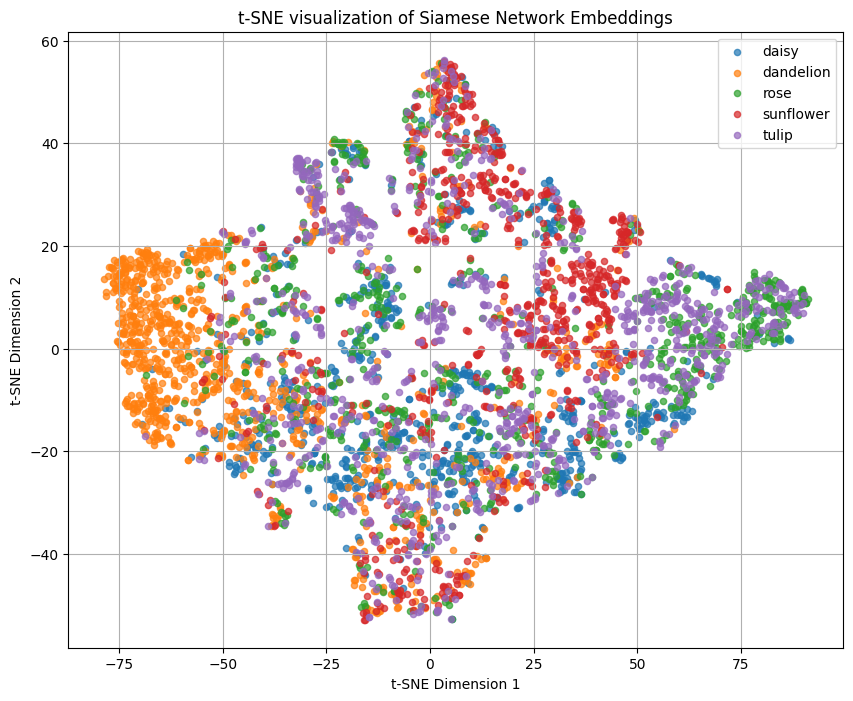

In [60]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Run t-SNE on all features (or subset if too big)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(features)  # features from get_features()

# Convert labels to numpy array
labels_np = np.array(labels)

# Plotting
plt.figure(figsize=(10, 8))

for class_idx, class_name in enumerate(class_names):
    idxs = labels_np == class_idx
    plt.scatter(tsne_result[idxs, 0], tsne_result[idxs, 1], label=class_name, alpha=0.7, s=20)

plt.legend()
plt.title('t-SNE visualization of Siamese Network Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()


In [59]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define your transforms (modify as needed)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load your dataset (replace path with your actual data directory)
data_dir = "/kaggle/input/flowers-recognition/flowers"
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Create DataLoader for feature extraction
test_loader = DataLoader(dataset, batch_size=32, shuffle=False)

# Feature Extraction Function
def get_features(model, dataloader):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for x, y in tqdm(dataloader):
            x = x.to(device)
            feat = model.forward_once(x)  # assuming your model has forward_once method
            features.append(feat.cpu())
            labels.extend(y.cpu().numpy())
    return torch.cat(features).numpy(), labels

# Assuming your model is already loaded and on the device
model.to(device)

# Step 1: Extract features and labels
features, labels = get_features(model, test_loader)

# Step 2: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

# Step 3: Normalize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Train Logistic Regression Classifier
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

# Step 5: Predict and Evaluate
y_pred = clf.predict(X_test_scaled)

# Step 6: Class Names
class_names = dataset.classes  # This automatically matches ImageFolder classes

print(classification_report(y_test, y_pred, target_names=class_names))


100%|██████████| 135/135 [00:28<00:00,  4.73it/s]


              precision    recall  f1-score   support

       daisy       0.79      0.78      0.79       153
   dandelion       0.87      0.86      0.87       210
        rose       0.72      0.72      0.72       157
   sunflower       0.80      0.87      0.83       147
       tulip       0.77      0.74      0.75       197

    accuracy                           0.79       864
   macro avg       0.79      0.79      0.79       864
weighted avg       0.79      0.79      0.79       864



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
